## Dataset

1. We use the Bank Marketing Dataset from the UCI Machine Learning Repository.
Source: https://archive.ics.uci.edu/ml/datasets/bank+marketing

2. The data is related with direct marketing campaigns (phone calls) of a Portuguese banking institution. Originally designed for supervised learning, but we will ignore the label initially

Important Decision:

Even though the dataset contains subscribed (whether the client subscribed to a term deposit), we do not use it to train the clustering model.
We may, however, use it later for interpretation only.

    # bank client data:
    1 - age (numeric)
    2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
    3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
    4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
    5 - default: has credit in default? (categorical: 'no','yes','unknown')
    6 - housing: has housing loan? (categorical: 'no','yes','unknown')
    7 - loan: has personal loan? (categorical: 'no','yes','unknown')
    # related with the last contact of the current campaign:
    8 - contact: contact communication type (categorical: 'cellular','telephone')
    9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
    10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
    11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
    # other attributes:
    12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
    13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
    14 - previous: number of contacts performed before this campaign and for this client (numeric)
    15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
    # social and economic context attributes
    16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
    17 - cons.price.idx: consumer price index - monthly indicator (numeric)
    18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
    19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
    20 - nr.employed: number of employees - quarterly indicator (numeric)
    21 - y - has the client subscribed a term deposit? (binary: 'yes','no')

## task 1

### Requirements

The goal of this lab is to **explore the bank dataset, prepare it for clustering, and apply K-Means**.  
Follow these steps carefully and write down your observations.  

### **Exploratory Data Analysis (EDA)** (understanding the dataset and its characteristics)

For each feature, you should:

- Identify **numeric vs categorical features**  
- Check **distributions** of numeric features (min, max, mean, std, skewness)  
- Check **counts of categories** for categorical features  
- Identify **missing or unknown values** and decide how to handle them  
- Look for **correlations** between numeric features  
- Identify **outliers** that may affect clustering  

In [1]:
!pip install ucimlrepo

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from ucimlrepo import fetch_ucirepo

bank_marketing = fetch_ucirepo(id=222)

X = bank_marketing.data.features
y = bank_marketing.data.targets

df = pd.concat([X, y.rename(columns={y.columns[0]: 'y'})], axis=1)
print("shape:", df.shape)
print(df.head())
print(df.dtypes)

shape: (45211, 17)
   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married        NaN      no     1506     yes   no   
4   33           NaN   single        NaN      no        1      no   no   

  contact  day_of_week month  duration  campaign  pdays  previous poutcome   y  
0     NaN            5   may       261         1     -1         0      NaN  no  
1     NaN            5   may       151         1     -1         0      NaN  no  
2     NaN            5   may        76         1     -1         0      NaN  no  
3     NaN            5   may        92         1     -1         0      NaN  no  
4     NaN            5   may       198         1     -1         0      NaN  no  
age             int64
job            object
marita

In [ ]:
df

,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN,no
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN,no
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN,no
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,NaN,yes
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,NaN,yes
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,NaN,no


In [4]:
# split into numeric and categorical
numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = df.select_dtypes(include=['object']).columns.tolist()

print("numeric:", numeric_features)
print("categorical:", categorical_features)

# check missing values
missing = df.isnull().sum()
print("\nmissing values:")
print(missing[missing > 0])

numeric: ['age', 'balance', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous']
categorical: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'y']

missing values:
job            288
education     1857
contact      13020
poutcome     36959
dtype: int64


In [ ]:
# distributions of numeric features
for col in numeric_features:
    print(f"\n{col}:")
    print(df[col].describe())
    print(f"skewness: {df[col].skew():.3f}")


age:
count    45211.000000
mean        40.936210
std         10.618762
min         18.000000
25%         33.000000
50%         39.000000
75%         48.000000
max         95.000000
Name: age, dtype: float64
skewness: 0.685

balance:
count     45211.000000
mean       1362.272058
std        3044.765829
min       -8019.000000
25%          72.000000
50%         448.000000
75%        1428.000000
max      102127.000000
Name: balance, dtype: float64
skewness: 8.360

day_of_week:
count    45211.000000
mean        15.806419
std          8.322476
min          1.000000
25%          8.000000
50%         16.000000
75%         21.000000
max         31.000000
Name: day_of_week, dtype: float64
skewness: 0.093

duration:
count    45211.000000
mean       258.163080
std        257.527812
min          0.000000
25%        103.000000
50%        180.000000
75%        319.000000
max       4918.000000
Name: duration, dtype: float64
skewness: 3.144

campaign:
count    45211.000000
mean         2.763841
std    

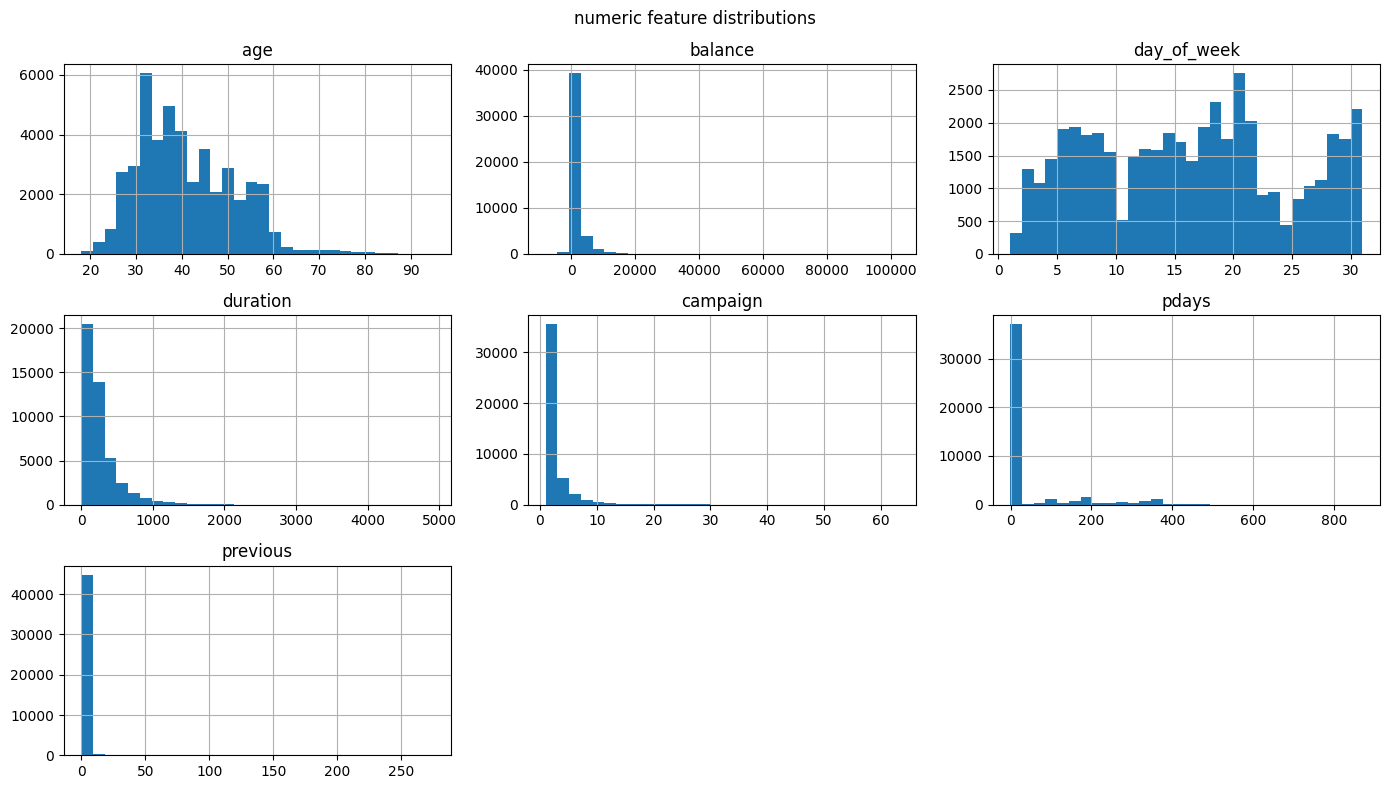

In [ ]:
# plot distributions
df[numeric_features].hist(figsize=(14, 8), bins=30)
plt.suptitle('numeric feature distributions')
plt.tight_layout()
plt.show()

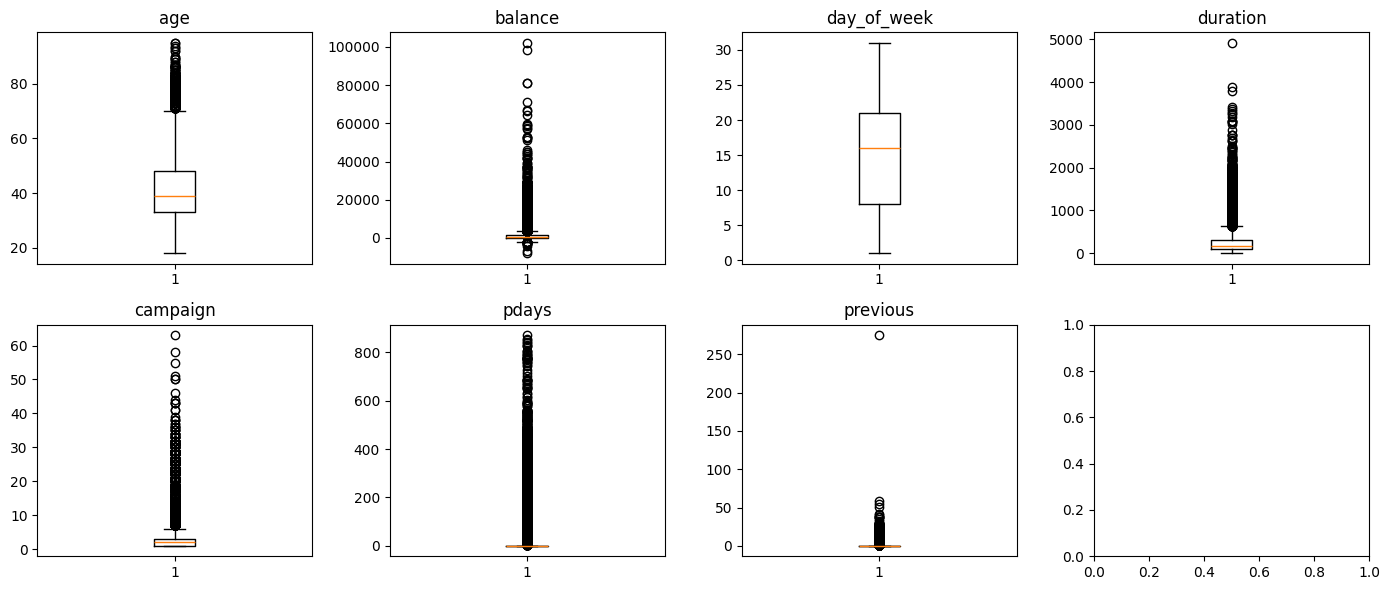

In [ ]:
# boxplots to see outliers
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
axes = axes.flatten()
for i, col in enumerate(numeric_features):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

In [5]:
# categorical counts
for col in categorical_features:
    print(f"\n{col}:")
    print(df[col].value_counts(dropna=False))


job:
job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
NaN               288
Name: count, dtype: int64

marital:
marital
married     27214
single      12790
divorced     5207
Name: count, dtype: int64

education:
education
secondary    23202
tertiary     13301
primary       6851
NaN           1857
Name: count, dtype: int64

default:
default
no     44396
yes      815
Name: count, dtype: int64

housing:
housing
yes    25130
no     20081
Name: count, dtype: int64

loan:
loan
no     37967
yes     7244
Name: count, dtype: int64

contact:
contact
cellular     29285
NaN          13020
telephone     2906
Name: count, dtype: int64

month:
month
may    13766
jul     6895
aug     6247
jun     5341
nov     3970
apr     2932
feb     2649
jan     1403
oct      738
sep      579
mar      477
dec      214
Nam

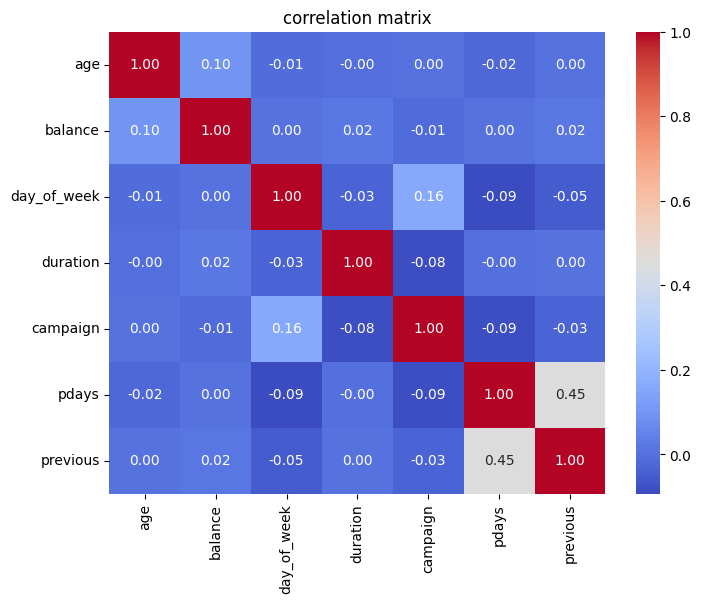

In [ ]:
# correlation between numeric features
corr = df[numeric_features].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('correlation matrix')
plt.show()

### **Data Preparation**

Before applying K-Means:

- Drop irrelevant or target columns
- Encode categorical features into numeric format
- Scale numeric features so all are comparable for distance calculations  
- Check that the final dataset has **no missing values** and **all features are numeric**  

In [ ]:
# drop y (target) and duration (leaks the label)
df_clean = df.drop(columns=['y', 'duration'])
print("shape after drop:", df_clean.shape)
print(df_clean.columns.tolist())

# handle unknown values - replace with mode
remaining_cat = [c for c in categorical_features if c not in ['y', 'duration']]
for col in remaining_cat:
    n_unk = (df_clean[col] == 'unknown').sum()
    if n_unk > 0:
        mode_val = df_clean[df_clean[col] != 'unknown'][col].mode()[0]
        df_clean[col] = df_clean[col].replace('unknown', mode_val)
        print(f"{col}: replaced {n_unk} unknowns with '{mode_val}'")

shape after drop: (45211, 15)
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day_of_week', 'month', 'campaign', 'pdays', 'previous', 'poutcome']


In [ ]:
# encode categorical columns
df_encoded = df_clean.copy()
le = LabelEncoder()
for col in remaining_cat:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

print(df_encoded.head())
print("\nshape:", df_encoded.shape)

   age  job  marital  education  default  balance  housing  loan  contact  \
0   58    4        1          3        0     2143        1     0        1   
1   44   10        2          2        0       29        1     0        1   
2   33    2        1          2        0        2        1     1        1   
3   47    1        1          0        0     1506        1     0        1   
4   33    5        2          0        0        1        0     0        1   

   day_of_week  month  campaign  pdays  previous  poutcome  
0            5      8         1     -1         0         1  
1            5      8         1     -1         0         1  
2            5      8         1     -1         0         1  
3            5      8         1     -1         0         1  
4            5      8         1     -1         0         1  

shape: (45211, 15)


In [ ]:
# scale everything
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_encoded), columns=df_encoded.columns)

print("missing values:", df_scaled.isnull().sum().sum())
print("all numeric:", all(df_scaled.dtypes != object))
print("final shape:", df_scaled.shape)

missing values: 0
all numeric: True
final shape: (45211, 15)


### **Apply K-Means Clustering**

- Decide an initial number of clusters (K)  
- Fit the K-Means model to your prepared dataset  
- Assign each data point to a cluster

In [ ]:
# start with k=3 as a guess
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(df_scaled)

print("inertia:", kmeans.inertia_)
print("cluster sizes:", pd.Series(kmeans.labels_).value_counts().sort_index())

inertia: 576904.3986958015
cluster sizes: 0    21154
1    18326
2     5731
Name: count, dtype: int64


In [ ]:
# add cluster labels to the original df to inspect
df['cluster'] = kmeans.labels_

# look at average feature values per cluster
print(df.groupby('cluster')[numeric_features].mean().round(2))

           age  balance  day_of_week  duration  campaign   pdays  previous
cluster                                                                   
0        41.11  1263.31        15.46    256.63      2.68    3.53      0.08
1        40.99  1470.95        16.84    263.55      3.07   12.72      0.27
2        40.10  1380.02        13.79    246.58      2.09  263.41      3.43


In [ ]:
# check subscription rate per cluster (just for interpretation)
print(df.groupby('cluster')['y'].apply(lambda x: (x=='yes').mean()).round(3))

cluster
0    0.074
1    0.161
2    0.134
Name: y, dtype: float64


### **Choosing the Convenient K**

- Use **Elbow Method**: plot Sum of Squared Distances (SSD) vs K  
- Identify the **elbow point** where SSD reduction slows  
- Calculate **Silhouette scores** to validate K  

In [ ]:
# try k from 2 to 10
K_range = range(2, 11)
inertias = []
silhouette_scores = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(df_scaled)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(df_scaled, labels))
    print(f"k={k}  inertia={km.inertia_:.2f}  silhouette={silhouette_scores[-1]:.4f}")

k=2  inertia=623748.93  silhouette=0.2034
k=3  inertia=576904.40  silhouette=0.1066
k=4  inertia=532608.75  silhouette=0.1166
k=5  inertia=505365.18  silhouette=0.1026
k=6  inertia=474290.65  silhouette=0.1223
k=7  inertia=442197.13  silhouette=0.1193
k=8  inertia=420360.92  silhouette=0.1316
k=9  inertia=405767.95  silhouette=0.1248
k=10  inertia=387270.35  silhouette=0.1229


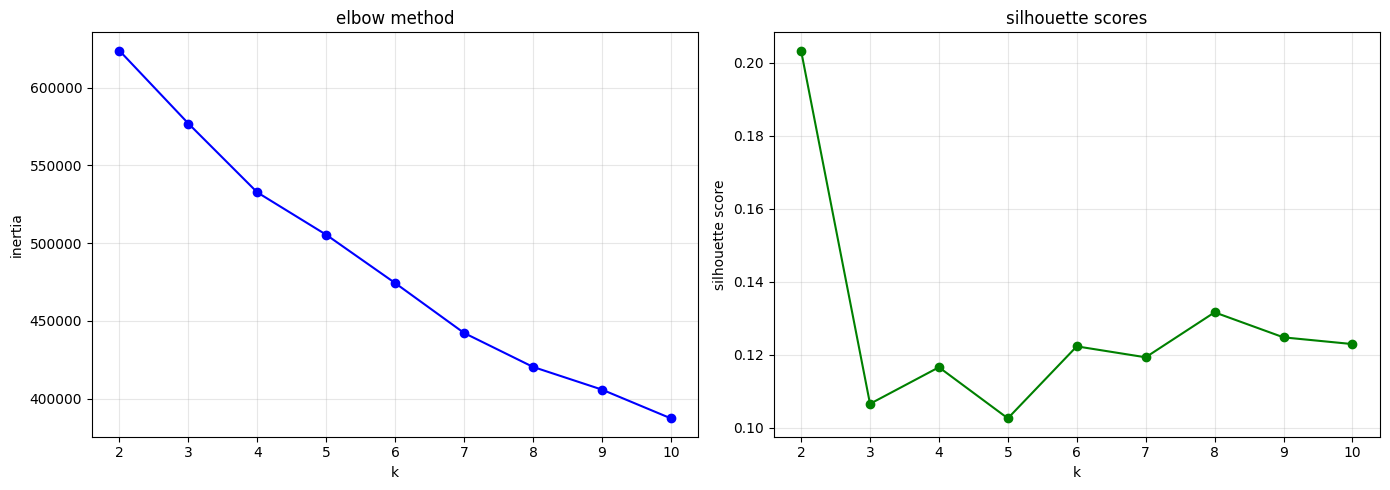

In [ ]:
# elbow and silhouette plots side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, 'bo-')
axes[0].set_xlabel('k')
axes[0].set_ylabel('inertia')
axes[0].set_title('elbow method')
axes[0].grid(alpha=0.3)

axes[1].plot(K_range, silhouette_scores, 'go-')
axes[1].set_xlabel('k')
axes[1].set_ylabel('silhouette score')
axes[1].set_title('silhouette scores')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# pick best k based on silhouette
best_k = list(K_range)[np.argmax(silhouette_scores)]
print(f"best k = {best_k} with silhouette score {max(silhouette_scores):.4f}")

# also look at inertia drops to confirm elbow
diffs = np.diff(inertias)
print("\ninertia drops:")
for k, d in zip(list(K_range)[1:], diffs):
    print(f"  k={k-1} to k={k}: {d:.2f}")

best k = 2 with silhouette score 0.2034

inertia drops:
  k=2 to k=3: -46844.53
  k=3 to k=4: -44295.65
  k=4 to k=5: -27243.57
  k=5 to k=6: -31074.53
  k=6 to k=7: -32093.52
  k=7 to k=8: -21836.21
  k=8 to k=9: -14592.97
  k=9 to k=10: -18497.60


In [ ]:
# final model with optimal k
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
final_labels = kmeans_final.fit_predict(df_scaled)

print(f"final k={best_k}")
print(f"inertia: {kmeans_final.inertia_:.4f}")
print(f"silhouette: {silhouette_score(df_scaled, final_labels):.4f}")

print("\ncluster sizes:")
print(pd.Series(final_labels).value_counts().sort_index())

# per-cluster silhouette
sil_vals = silhouette_samples(df_scaled, final_labels)
for i in range(best_k):
    vals = sil_vals[final_labels == i]
    print(f"cluster {i}: mean={vals.mean():.4f}  std={vals.std():.4f}")

final k=2
inertia: 623748.9322
silhouette: 0.2034

cluster sizes:
0    39181
1     6030
Name: count, dtype: int64
cluster 0: mean=0.2190  std=0.0453
cluster 1: mean=0.1015  std=0.0828
